In [1]:
# ---- 1. Setup ----
import os
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

sns.set_style("whitegrid")

DATA_ROOT = Path("../data/Surface Crack Detection")

In [2]:

#---- 2. Create output directory ----
# Output folder for generated charts/CSVs
OUT_DIR = Path("eda_outputs")
OUT_DIR.mkdir(exist_ok=True)

VALID_EXTS = {".jpg", ".jpeg", ".png"}


classes = sorted([d.name for d in DATA_ROOT.iterdir() if d.is_dir()])
print(f"Found {len(classes)} classes: {classes}")

Found 4 classes: ['Cracks', 'Patch', 'Potholes', 'Surface_Defects']


In [3]:

# ---- 3. Walk the dataset and collect per-image metadata ----
records = []
for cls in classes:
    cls_dir = DATA_ROOT / cls
    image_paths = [
        p for p in cls_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in VALID_EXTS
    ]
    for fpath in image_paths:
        try:
            with Image.open(fpath) as im:
                w, h = im.size
                mode = im.mode
                fmt = im.format
            size_kb = fpath.stat().st_size / 1024
            records.append({
                "class": cls,
                "filename": fpath.name,
                "filepath": str(fpath),
                "width": w,
                "height": h,
                "aspect_ratio": round(w / h, 3),
                "mode": mode,
                "format": fmt,
                "size_kb": round(size_kb, 1),
                "corrupt": False,
            })
        except Exception as e:
            records.append({
                "class": cls,
                "filename": fpath.name,
                "filepath": str(fpath),
                "width": None,
                "height": None,
                "aspect_ratio": None,
                "mode": None,
                "format": None,
                "size_kb": fpath.stat().st_size / 1024,
                "corrupt": True,
            })
            print(f"[WARN] Could not open {fpath}: {e}")

df = pd.DataFrame(records)
print(f"Total images found: {len(df)}")
df.head()

Total images found: 400


,class,filename,filepath,width,height,aspect_ratio,mode,format,size_kb,corrupt
0,Cracks,1.jpg,..\data\Surface Crack Detection\Cracks\Cracks\...,1289,1744,0.739,RGB,JPEG,818.5,False
1,Cracks,10.jpg,..\data\Surface Crack Detection\Cracks\Cracks\...,1053,1287,0.818,RGB,JPEG,452.1,False
2,Cracks,100.jpg,..\data\Surface Crack Detection\Cracks\Cracks\...,1711,1429,1.197,RGB,JPEG,620.0,False
3,Cracks,102.jpg,..\data\Surface Crack Detection\Cracks\Cracks\...,1831,1551,1.181,RGB,JPEG,767.6,False
4,Cracks,103.jpg,..\data\Surface Crack Detection\Cracks\Cracks\...,2372,1504,1.577,RGB,JPEG,1227.7,False


In [4]:
# ---- 4. Basic sanity checks ----
print("Images per class:")
print(df.groupby("class").size())

print(f"\nCorrupt files: {df['corrupt'].sum()}")

print("\nFile formats:")
print(df["format"].value_counts())

print("\nColor modes:")
print(df["mode"].value_counts())

# Check for duplicate images via file hash (exact byte-for-byte duplicates)
def file_hash(path, block_size=65536):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(block_size), b""):
            h.update(chunk)
    return h.hexdigest()

df["hash"] = df["filepath"].apply(file_hash)
dupes = df[df.duplicated("hash", keep=False)].sort_values("hash")
print(f"\nExact duplicate files: {len(dupes)} (across {dupes['hash'].nunique()} groups)")
if len(dupes):
    print(dupes[["class", "filename", "hash"]])

Images per class:
class
Cracks             100
Patch              100
Potholes           100
Surface_Defects    100
dtype: int64

Corrupt files: 0

File formats:
format
JPEG    400
Name: count, dtype: int64

Color modes:
mode
RGB    400
Name: count, dtype: int64

Exact duplicate files: 0 (across 0 groups)


In [5]:
# ---- 5. Numeric summary stats ----
print(df[["width", "height", "size_kb", "aspect_ratio"]].describe().round(2))

print("\nPer-class summary:")
print(df.groupby("class")[["width", "height", "size_kb", "aspect_ratio"]]
        .agg(["mean", "std", "min", "max"]).round(2))


         width   height  size_kb  aspect_ratio
count   400.00   400.00   400.00        400.00
mean   1834.96  1376.54   997.28          1.40
std     798.10   625.09   754.42          0.38
min     283.00   183.00    32.40          0.67
25%    1209.00   937.75   358.22          1.14
50%    1835.50  1358.00   885.80          1.34
75%    2344.75  1731.25  1479.70          1.59
max    4031.00  3191.00  3646.80          2.85

Per-class summary:
                   width                      height                     \
                    mean     std  min   max     mean     std  min   max   
class                                                                     
Cracks           1623.97  560.62  384  2888  1272.83  448.11  362  2362   
Patch            2323.20  970.42  472  4031  1673.28  797.46  230  3191   
Potholes         1399.84  655.94  283  2971  1065.69  534.15  183  2145   
Surface_Defects  1992.82  615.43  560  3829  1494.38  491.22  383  2980   

                 size_kb       

In [6]:
# ---- 6. Brightness & contrast per image ----
# Downscale to speed this up; grayscale mean = brightness, std = contrast
brightness, contrast = [], []
for fp in df["filepath"]:
    with Image.open(fp) as im:
        small = im.convert("L").resize((128, 128))
        arr = np.asarray(small, dtype=np.float32)
        brightness.append(arr.mean())
        contrast.append(arr.std())

df["brightness"] = brightness
df["contrast"] = contrast

print(df.groupby("class")[["brightness", "contrast"]].mean().round(2))

# Save enriched metadata for later use (e.g. in your training pipeline)
df.to_csv(OUT_DIR / "image_metadata.csv", index=False)
print(f"\nSaved metadata to {OUT_DIR / 'image_metadata.csv'}")


                 brightness  contrast
class                                
Cracks           162.220001     15.88
Patch            165.399994     12.17
Potholes         156.149994     18.26
Surface_Defects  157.429993     13.40

Saved metadata to eda_outputs\image_metadata.csv


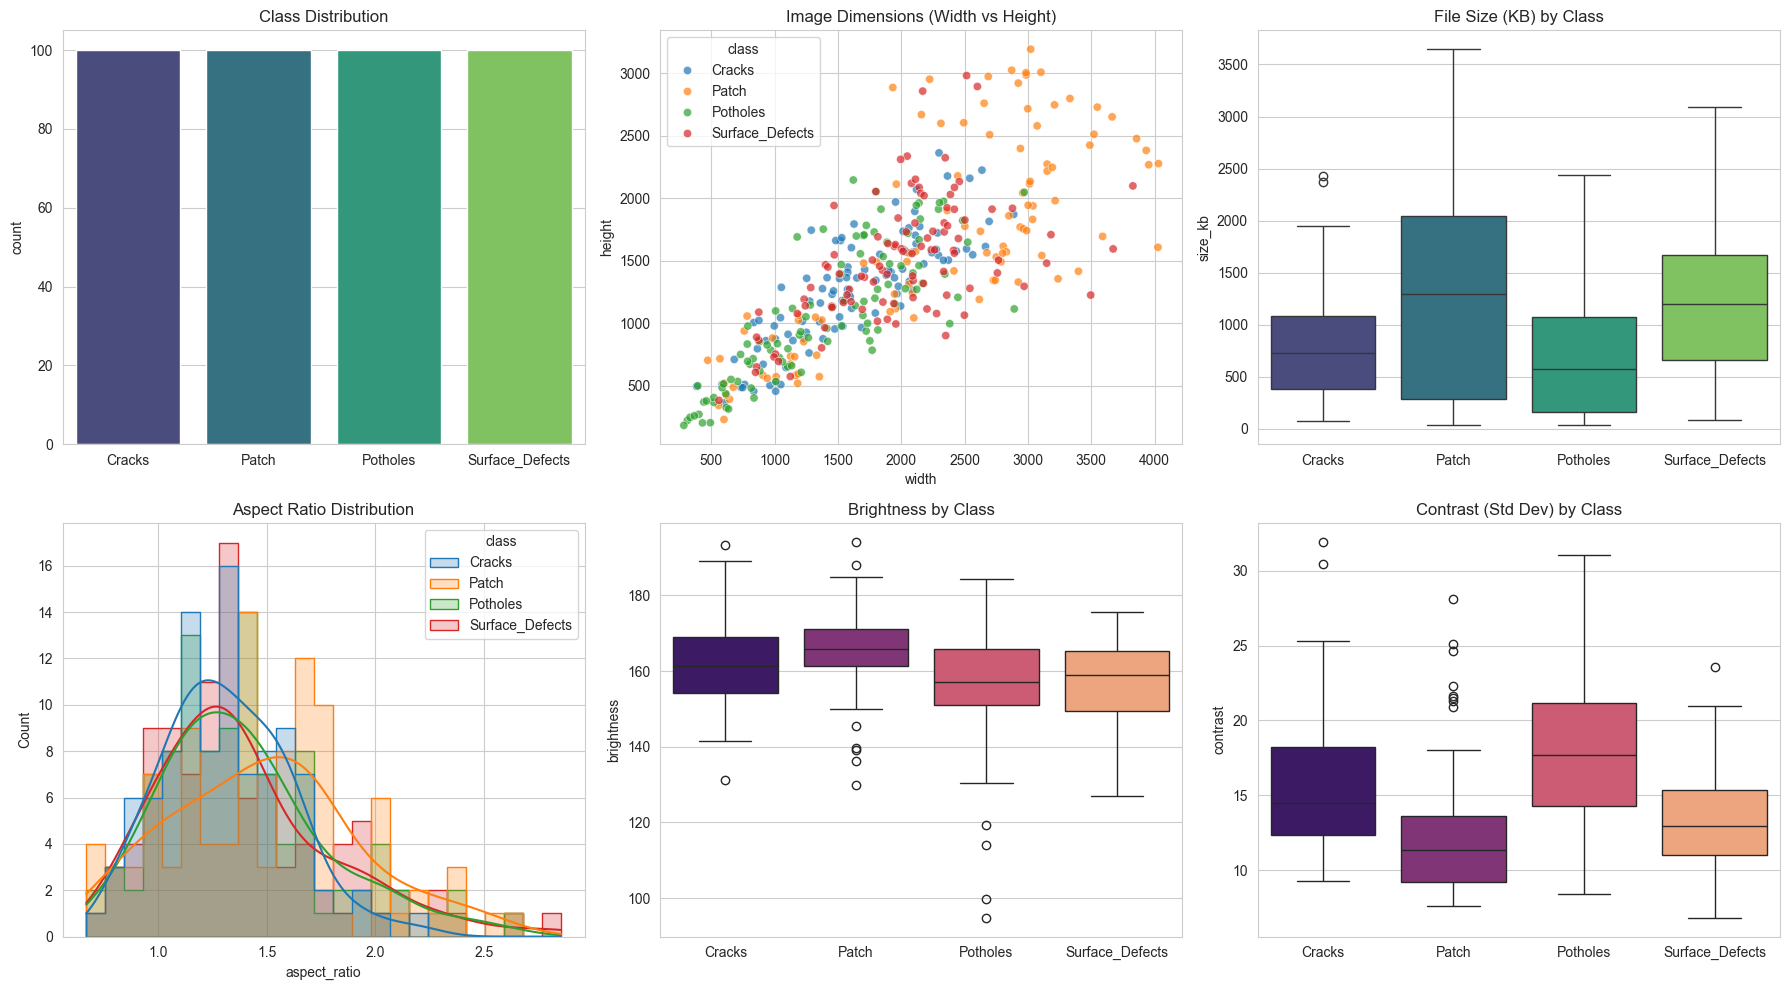

In [7]:
# ---- 7. Visual EDA: 6-panel overview ----
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.countplot(data=df, x="class", hue="class", palette="viridis",
              legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Class Distribution")
axes[0, 0].set_xlabel("")

sns.scatterplot(data=df, x="width", y="height", hue="class",
                 alpha=0.7, ax=axes[0, 1])
axes[0, 1].set_title("Image Dimensions (Width vs Height)")

sns.boxplot(data=df, x="class", y="size_kb", hue="class",
            palette="viridis", legend=False, ax=axes[0, 2])
axes[0, 2].set_title("File Size (KB) by Class")
axes[0, 2].set_xlabel("")

sns.histplot(data=df, x="aspect_ratio", hue="class", kde=True,
             bins=25, element="step", ax=axes[1, 0])
axes[1, 0].set_title("Aspect Ratio Distribution")

sns.boxplot(data=df, x="class", y="brightness", hue="class",
            palette="magma", legend=False, ax=axes[1, 1])
axes[1, 1].set_title("Brightness by Class")
axes[1, 1].set_xlabel("")

sns.boxplot(data=df, x="class", y="contrast", hue="class",
            palette="magma", legend=False, ax=axes[1, 2])
axes[1, 2].set_title("Contrast (Std Dev) by Class")
axes[1, 2].set_xlabel("")

plt.tight_layout()
plt.savefig(OUT_DIR / "eda_overview.png", dpi=150)
plt.show()

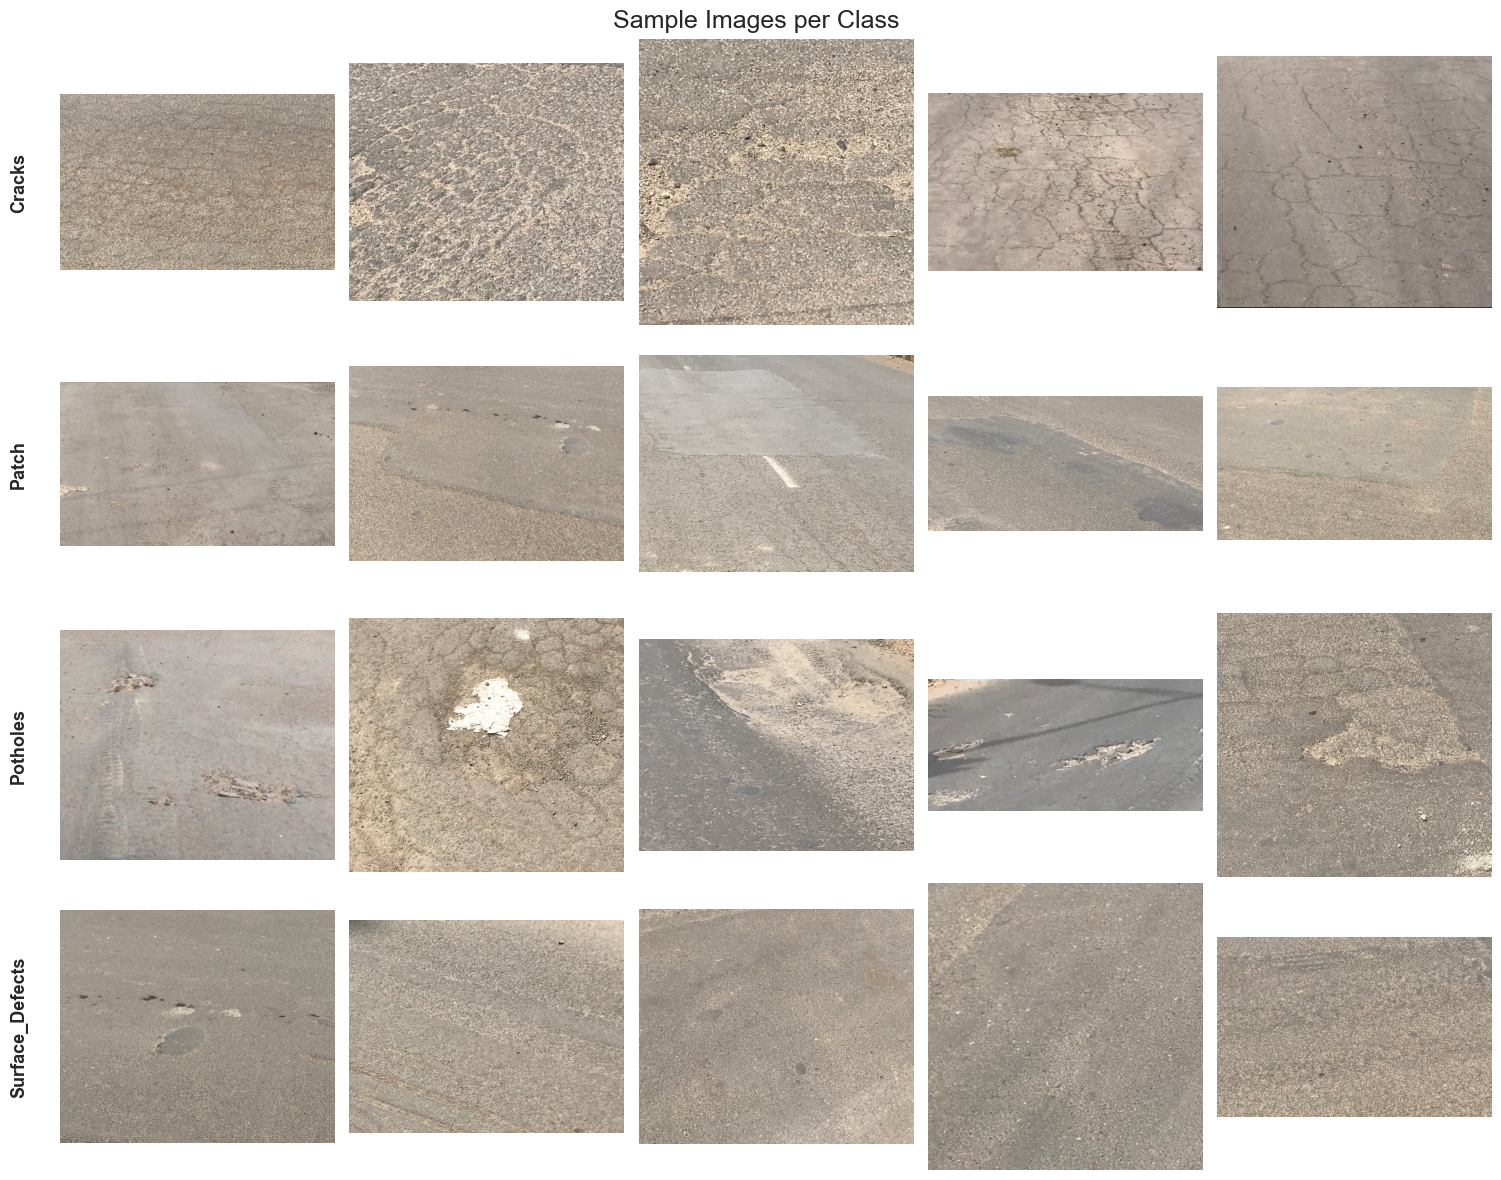

In [8]:
# ---- 8. Sample image grid (5 random images per class) ----
n_samples = 5
fig, axes = plt.subplots(len(classes), n_samples, figsize=(3 * n_samples, 3 * len(classes)))

for i, cls in enumerate(classes):
    sub = df[df["class"] == cls].sample(min(n_samples, len(df[df["class"] == cls])),
                                          random_state=42)
    for j, (_, row) in enumerate(sub.iterrows()):
        ax = axes[i, j] if len(classes) > 1 else axes[j]
        img = Image.open(row["filepath"])
        ax.imshow(img)
        ax.axis("off")
        if j == 0:
            ax.text(-0.15, 0.5, cls, transform=ax.transAxes, rotation=90,
                     va="center", ha="center", fontsize=13, fontweight="bold")

plt.suptitle("Sample Images per Class", fontsize=18)
plt.tight_layout()
plt.savefig(OUT_DIR / "sample_images_grid.png", dpi=150)
plt.show()

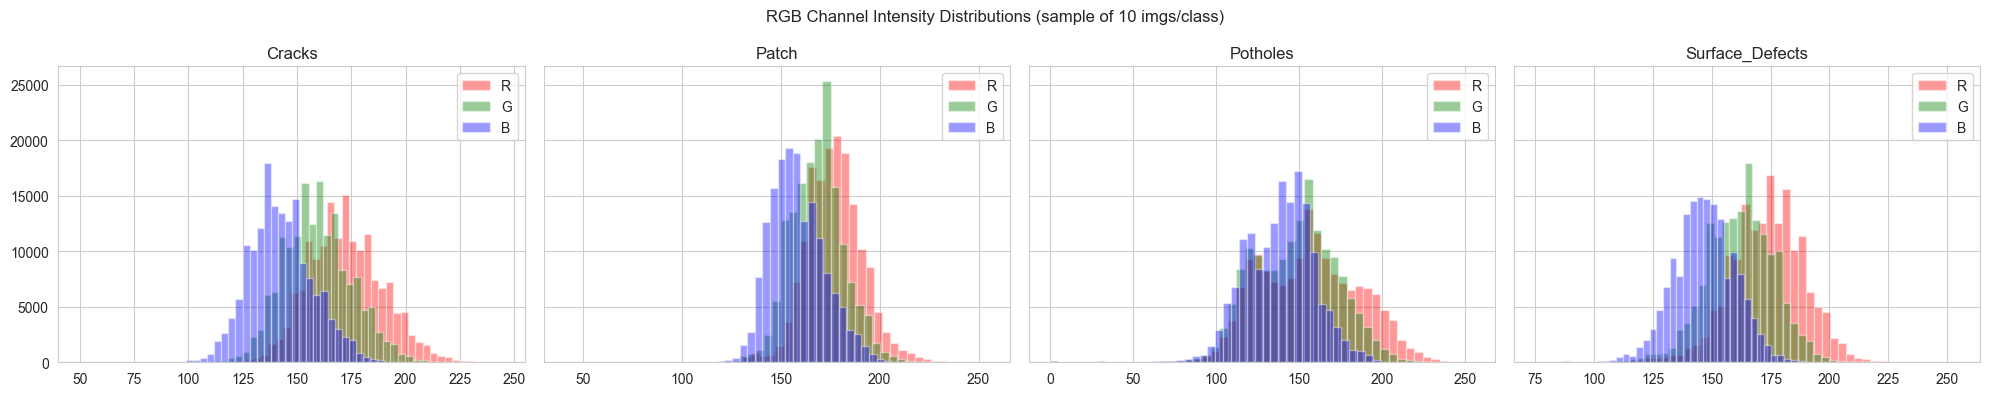

In [9]:
# ---- 9. Pixel intensity histograms per class (color channels) ----
# Gives a sense of color/lighting differences across classes
fig, axes = plt.subplots(1, len(classes), figsize=(5 * len(classes), 4), sharey=True)

for i, cls in enumerate(classes):
    sample_files = df[df["class"] == cls]["filepath"].sample(
        min(10, len(df[df["class"] == cls])), random_state=1)
    r_vals, g_vals, b_vals = [], [], []
    for fp in sample_files:
        im = Image.open(fp).convert("RGB").resize((128, 128))
        arr = np.asarray(im)
        r_vals.append(arr[:, :, 0].ravel())
        g_vals.append(arr[:, :, 1].ravel())
        b_vals.append(arr[:, :, 2].ravel())
    ax = axes[i] if len(classes) > 1 else axes
    ax.hist(np.concatenate(r_vals), bins=50, color="red", alpha=0.4, label="R")
    ax.hist(np.concatenate(g_vals), bins=50, color="green", alpha=0.4, label="G")
    ax.hist(np.concatenate(b_vals), bins=50, color="blue", alpha=0.4, label="B")
    ax.set_title(cls)
    ax.legend()

plt.suptitle("RGB Channel Intensity Distributions (sample of 10 imgs/class)")
plt.tight_layout()
plt.savefig(OUT_DIR / "rgb_histograms.png", dpi=150)
plt.show()

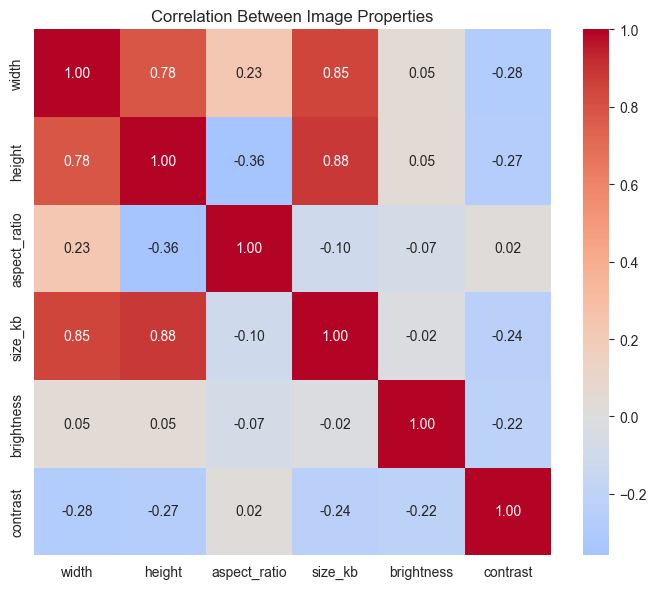

In [10]:
# ---- 10. Correlation heatmap of numeric image properties ----
numeric_cols = ["width", "height", "aspect_ratio", "size_kb", "brightness", "contrast"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Between Image Properties")
plt.tight_layout()
plt.savefig(OUT_DIR / "correlation_heatmap.png", dpi=150)
plt.show()

In [11]:
# ---- 11. Wrap-up: quick text summary ----
summary = f"""
EDA SUMMARY
-----------
Total images       : {len(df)}
Classes             : {classes}
Images per class    : {dict(df.groupby('class').size())}
Corrupt files        : {df['corrupt'].sum()}
Exact duplicates     : {len(dupes)}
Width range (px)     : {df['width'].min()} - {df['width'].max()}
Height range (px)    : {df['height'].min()} - {df['height'].max()}
File size range (KB) : {df['size_kb'].min():.1f} - {df['size_kb'].max():.1f}
"""
print(summary)

with open(OUT_DIR / "eda_summary.txt", "w") as f:
    f.write(summary)

print(f"All outputs saved in: {OUT_DIR.resolve()}")


EDA SUMMARY
-----------
Total images       : 400
Classes             : ['Cracks', 'Patch', 'Potholes', 'Surface_Defects']
Images per class    : {'Cracks': np.int64(100), 'Patch': np.int64(100), 'Potholes': np.int64(100), 'Surface_Defects': np.int64(100)}
Corrupt files        : 0
Exact duplicates     : 0
Width range (px)     : 283 - 4031
Height range (px)    : 183 - 3191
File size range (KB) : 32.4 - 3646.8

All outputs saved in: C:\Users\varsh\OneDrive\Desktop\bootcamp-ace-26-team-7\notebooks\eda_outputs
